# 01 — Gradient Boosting Fundamentals

**Estimated time:** 100–130 minutes  
**Prerequisites:** notebook 00, decision trees, train/validation splits, and basic classification metrics.  
**Dataset:** local Bank Marketing data from `data/raw/bank-full.csv`.  
**Practical theme:** build a strong baseline, then decide whether gradient boosting earns its extra complexity.

## Learning objectives

By the end of this notebook, students should be able to:

- Explain gradient boosting as a sequence of small correction models.
- Connect residual fitting in regression to probability-error correction in binary classification.
- Keep preprocessing leakage-safe with scikit-learn pipelines.
- Compare gradient boosting with simple baselines using validation-aware metrics.
- Interpret the main capacity controls: `n_estimators`, `learning_rate`, and `max_depth`.
- Make a practical model recommendation that considers performance, simplicity, speed, and maintainability.

## Purpose

Gradient boosting is one of the most useful families of tabular machine-learning models. It can capture nonlinear patterns and feature interactions without heavy manual feature engineering. The trade-off is that it is usually slower and less transparent than a linear baseline.

In this lesson we will deliberately avoid clever helper code. The goal is to see the workflow clearly: load data, split it safely, preprocess inside pipelines, compare baselines, inspect learning curves, evaluate once on validation, and discuss whether the added complexity is justified.

## Common mistakes and leakage warnings

- Do not use `duration` for this business problem. It is only known after a phone call has happened, so it leaks future information.
- Do not fit encoders, imputers, or scalers before cross-validation. Put preprocessing inside the pipeline.
- Do not choose hyperparameters on the final test set. This course keeps the test set sealed until notebook 09.
- Do not judge an imbalanced classification problem with accuracy alone.
- Do not assume the most accurate model is the best operational choice.


## Concept: boosting as sequential correction

A shallow decision tree is a weak learner: by itself it is intentionally limited. Gradient boosting combines many weak learners **sequentially**. Each new tree is trained to reduce the current model's loss.

For squared-error regression, the correction target is easy to see: the residual.

\[
F_m(x) = F_{m-1}(x) + \eta h_m(x)
\]

`F_m` is the current ensemble, `h_m` is the new tree, and `η` is the learning rate. The newest tree is not the full model; it is one small update to the ensemble.

**Class discussion prompt:** Why might many shallow trees generalize better than one very deep tree?


### Gradient boosting workflow at a glance

![Gradient boosting workflow: begin with a constant prediction, calculate probability errors, fit a shallow correction tree, shrink its output, update the ensemble, and repeat sequentially.](../assets/gradient_boosting_process.png)

Read the process from left to right, then follow the loop back after the update step. Random-forest trees can be trained independently; boosting trees form an ordered chain because each tree depends on the current ensemble.


In [1]:
import json
import os
import platform
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", message="X does not have valid feature names.*")

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]


def project_root():
    return ROOT


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)


def fast_mode():
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}


def bank_data_path():
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(f"Expected local data at {path}")
    return path


def load_bank_data(include_duration=False):
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame


def stratified_sample(frame, n, seed=SEED):
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [
        group.sample(n=min(counts.loc[label], len(group)), random_state=seed + int(label))
        for label, group in frame.groupby(TARGET)
    ]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


def make_splits(frame=None, reduced=None):
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED
    )
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED
    )
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000, SEED)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))


def split_xy(frame):
    return frame.drop(columns=TARGET), frame[TARGET]


def feature_groups(frame):
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical


def make_preprocessor(frame, scale_numeric=True):
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ])


def classification_metrics(y_true, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "log_loss": log_loss(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "cost": float(fp + 5 * fn),
    }


def threshold_table(y_true, probability, thresholds=None):
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([
        {"threshold": float(t), **classification_metrics(y_true, probability, float(t))}
        for t in thresholds
    ])


def add_domain_features(frame):
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(
        result["age"], bins=[0, 29, 39, 49, 59, np.inf], labels=["<30", "30s", "40s", "50s", "60+"]
    ).astype("object")
    return result.drop(columns=["pdays"])


def environment_metadata():
    import sklearn
    return {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
    }


def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")


set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})


{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


## Data loading

We use the local course copy of the Bank Marketing dataset. The target is whether a client subscribed to a term deposit.

The original dataset includes `duration`, the call duration. That variable is highly predictive but unavailable before the call, so using it would produce an unrealistic model for campaign planning. The helper above drops it by default.


In [2]:
bank = load_bank_data()
development, validation, _sealed_test = make_splits(bank, reduced=FAST_MODE)
X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)

summary = pd.DataFrame({
    "rows": [len(development), len(validation)],
    "positive_rate": [y_dev.mean(), y_val.mean()],
}, index=["development", "validation"])

print("Columns used by the model:", X_dev.shape[1])
display(summary)
display(X_dev.head())


Columns used by the model: 15


,rows,positive_rate
development,12000,0.117
validation,4000,0.117


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,40,blue-collar,married,secondary,no,271,yes,no,unknown,29,may,2,-1,0,unknown
1,56,management,married,tertiary,no,1282,no,no,cellular,19,aug,4,-1,0,unknown
2,56,admin.,divorced,secondary,no,-429,no,yes,cellular,23,jul,4,-1,0,unknown
3,31,self-employed,single,tertiary,no,283,no,no,cellular,28,jan,2,241,1,failure
4,30,management,single,tertiary,no,61,yes,no,telephone,5,may,7,165,5,other


The positive class is relatively rare, so a model can look good on accuracy while still missing most subscribers. We will report accuracy, balanced accuracy, F1, and log loss.

**Teaching note:** Ask students which metric they would choose if every missed subscriber is much more expensive than every extra sales call.


## Preprocessing

The preprocessing step imputes missing numeric values, scales numeric columns, and one-hot encodes categorical columns. Scaling is not required for tree models, but it lets the same preprocessing pipeline work for logistic regression, which makes the baseline comparison fair and simple.

The important practice is that preprocessing lives inside the model pipeline. During cross-validation, each fold fits its own imputer, scaler, and encoder only on that fold's training rows.


In [3]:
numeric_features, categorical_features = feature_groups(X_dev)
print({
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
})


{'numeric_features': ['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], 'categorical_features': ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']}


## Build boosting by hand on a toy regression problem

Before modeling the bank data, we will build a small regression example. This makes the algorithm visible without classification math getting in the way.

Each stump predicts the current residuals. The learning rate shrinks the stump's contribution before adding it to the ensemble.


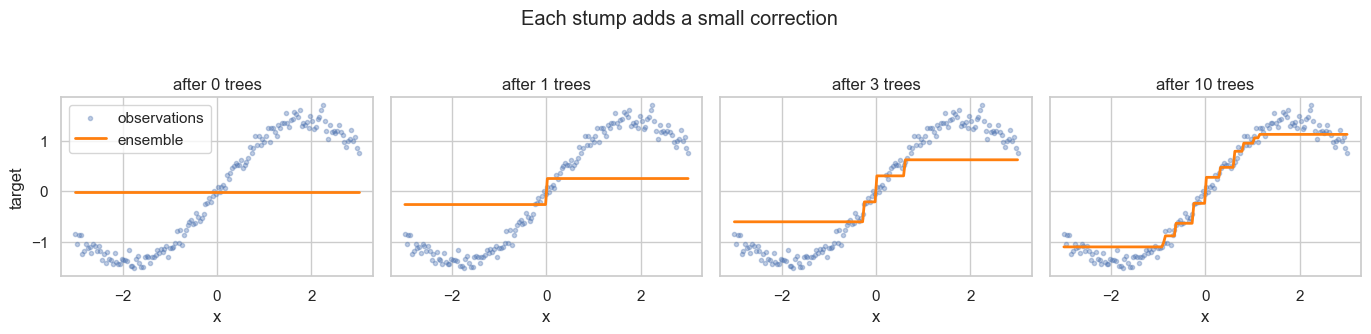

In [4]:
rng = np.random.default_rng(SEED)
x = np.linspace(-3, 3, 160)
y = np.sin(x) + 0.25 * x + rng.normal(0, 0.12, len(x))
X_toy = x.reshape(-1, 1)

learning_rate = 0.25
prediction = np.full_like(y, y.mean())
snapshots = {0: prediction.copy()}
toy_trees = []

for round_number in range(1, 11):
    residual = y - prediction
    tree = DecisionTreeRegressor(max_depth=1, random_state=SEED + round_number)
    tree.fit(X_toy, residual)
    prediction += learning_rate * tree.predict(X_toy)
    toy_trees.append(tree)
    if round_number in {1, 3, 10}:
        snapshots[round_number] = prediction.copy()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for axis, (round_number, stage_prediction) in zip(axes, snapshots.items()):
    axis.scatter(x, y, s=9, alpha=0.35, label="observations")
    axis.plot(x, stage_prediction, color="tab:orange", linewidth=2, label="ensemble")
    axis.set_title(f"after {round_number} trees")
    axis.set_xlabel("x")
axes[0].set_ylabel("target")
axes[0].legend(loc="upper left")
fig.suptitle("Each stump adds a small correction", y=1.04)
plt.tight_layout()
plt.show()


The staircase shape is expected because shallow trees produce piecewise-constant corrections. More boosting rounds make the ensemble more flexible. That flexibility is useful until the model starts fitting noise.


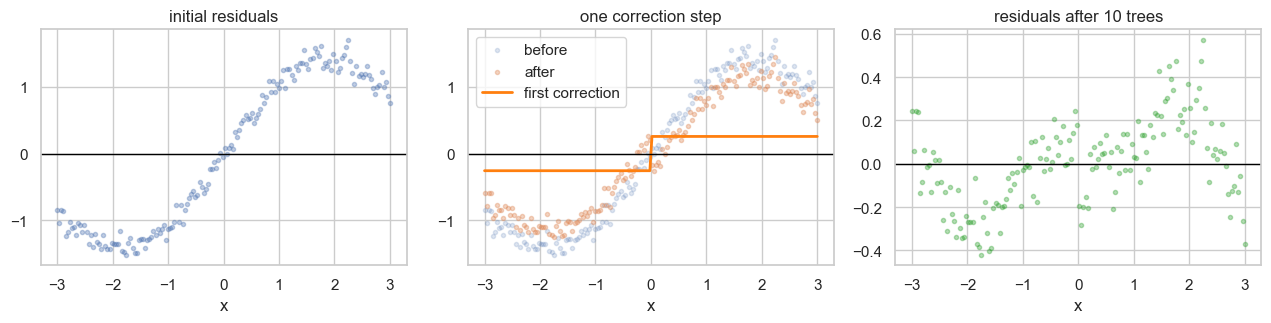

In [5]:
residual_0 = y - snapshots[0]
first_correction = learning_rate * toy_trees[0].predict(X_toy)
residual_1 = y - snapshots[1]
residual_final = y - snapshots[10]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharex=True)
axes[0].scatter(x, residual_0, s=9, alpha=0.35)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("initial residuals")

axes[1].scatter(x, residual_0, s=9, alpha=0.18, label="before")
axes[1].scatter(x, residual_1, s=9, alpha=0.35, label="after")
axes[1].plot(x, first_correction, color="tab:orange", linewidth=2, label="first correction")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("one correction step")
axes[1].legend()

axes[2].scatter(x, residual_final, s=9, alpha=0.35, color="tab:green")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("residuals after 10 trees")
for axis in axes:
    axis.set_xlabel("x")
plt.tight_layout()
plt.show()


## From residuals to classification gradients

Binary classification with gradient boosting usually minimizes log loss. The model updates scores that are converted into probabilities. A useful classroom approximation is:

`correction direction = observed label - current probability`

Large wrong probabilities get large corrections. Confident correct probabilities get small corrections.


In [6]:
gradient_example = pd.DataFrame({
    "observed_y": [1, 0, 1, 0],
    "current_probability": [0.10, 0.90, 0.80, 0.15],
})
gradient_example["y_minus_probability"] = (
    gradient_example["observed_y"] - gradient_example["current_probability"]
)
gradient_example["plain_language"] = [
    "strong upward correction",
    "strong downward correction",
    "small upward correction",
    "small downward correction",
]
display(gradient_example)


,observed_y,current_probability,y_minus_probability,plain_language
0,1,0.10,0.90,strong upward correction
1,0,0.90,-0.90,strong downward correction
2,1,0.80,0.20,small upward correction
3,0,0.15,-0.15,small downward correction


## Modeling: compare practical baselines first

A strong workflow does not jump straight to the advanced model. We compare three options:

- `always no`: a sanity-check baseline for an imbalanced dataset.
- logistic regression: fast, simple, and usually a serious first model.
- gradient boosting: more flexible, usually stronger on tabular nonlinear patterns, but slower and more complex.

All models use the same leakage-safe preprocessing pattern.


In [7]:
def make_model(model):
    return Pipeline([
        ("preprocess", make_preprocessor(X_dev, scale_numeric=True)),
        ("model", model),
    ])

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
cv_splits = list(cv.split(X_dev, y_dev))

candidate_models = {
    "always no": make_model(DummyClassifier(strategy="most_frequent")),
    "logistic regression": make_model(LogisticRegression(max_iter=1200, random_state=SEED)),
    "gradient boosting": make_model(GradientBoostingClassifier(
        n_estimators=120 if FAST_MODE else 220,
        learning_rate=0.05,
        max_depth=2,
        random_state=SEED,
    )),
}

rows = []
for name, estimator in candidate_models.items():
    scores = cross_validate(
        estimator,
        X_dev,
        y_dev,
        cv=cv_splits,
        scoring=["accuracy", "balanced_accuracy", "f1", "neg_log_loss"],
        n_jobs=-1,
    )
    rows.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "log_loss": -scores["test_neg_log_loss"].mean(),
        "accuracy_sd": scores["test_accuracy"].std(ddof=1),
    })

cv_results = pd.DataFrame(rows).set_index("model").sort_values("log_loss")
display(cv_results)


,accuracy,balanced_accuracy,f1,log_loss,accuracy_sd
model,,,,,
gradient boosting,0.888917,0.556179,0.203923,0.305093,0.000577
logistic regression,0.888083,0.562812,0.224104,0.307628,0.000878
always no,0.883000,0.500000,0.000000,4.217107,0.000000


## Evaluation: read the metrics as trade-offs

Accuracy is useful for communication, but it can hide weak minority-class performance. Balanced accuracy gives both classes equal weight. F1 focuses on positive-class precision and recall. Log loss evaluates probability quality, which matters when the business will rank customers by predicted likelihood.

The key teaching question is not “which number is biggest?” It is “which model gives enough benefit to justify its complexity?”


## Tune model capacity with an internal holdout

Three controls drive gradient boosting capacity:

| Parameter | Meaning | If too small | If too large |
|---|---|---|---|
| `n_estimators` | number of sequential trees | underfitting | extra compute and possible overfitting |
| `learning_rate` | size of each tree's contribution | needs more trees | corrections can be unstable |
| `max_depth` | interactions each tree can represent | misses structure | fits noise and becomes harder to explain |

We will choose the number of trees on an internal split of the development data. The course validation set is used only after this choice is made.


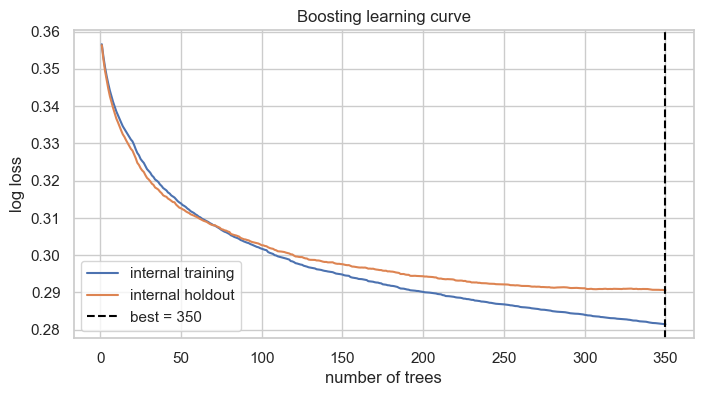

{'best_iteration': 350, 'best_internal_log_loss': 0.2906}


In [8]:
X_fit, X_stop, y_fit, y_stop = train_test_split(
    X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=SEED
)

curve_pipeline = make_model(GradientBoostingClassifier(
    n_estimators=350 if FAST_MODE else 500,
    learning_rate=0.05,
    max_depth=2,
    random_state=SEED,
))
curve_pipeline.fit(X_fit, y_fit)

curve_model = curve_pipeline.named_steps["model"]
X_fit_t = curve_pipeline.named_steps["preprocess"].transform(X_fit)
X_stop_t = curve_pipeline.named_steps["preprocess"].transform(X_stop)

train_loss = [log_loss(y_fit, p[:, 1]) for p in curve_model.staged_predict_proba(X_fit_t)]
stop_loss = [log_loss(y_stop, p[:, 1]) for p in curve_model.staged_predict_proba(X_stop_t)]
best_iteration = int(np.argmin(stop_loss) + 1)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_loss) + 1), train_loss, label="internal training")
plt.plot(range(1, len(stop_loss) + 1), stop_loss, label="internal holdout")
plt.axvline(best_iteration, color="black", linestyle="--", label=f"best = {best_iteration}")
plt.xlabel("number of trees")
plt.ylabel("log loss")
plt.title("Boosting learning curve")
plt.legend()
plt.show()

print({"best_iteration": best_iteration, "best_internal_log_loss": round(min(stop_loss), 4)})


A widening gap between training loss and holdout loss is a warning sign. More trees can keep improving the training objective even when generalization has stopped improving.

**Teaching note:** Ask students what would be wrong with selecting `best_iteration` using the final validation set and then reporting that same validation score.


## Refit once, then evaluate validation once

Now we refit the selected gradient boosting model on all development rows. This is the first time the validation split enters the notebook's model assessment.


,gradient boosting validation
accuracy,0.893250
balanced_accuracy,0.590144
f1,0.298851
log_loss,0.287210


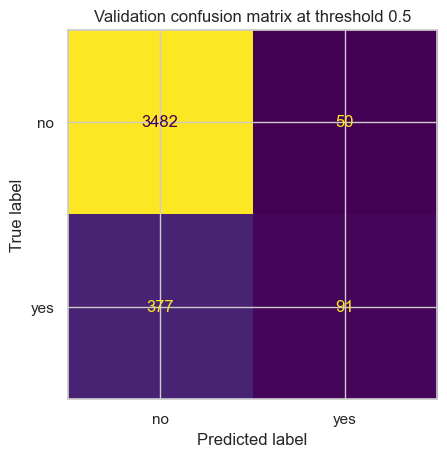

In [9]:
final_boosting = make_model(GradientBoostingClassifier(
    n_estimators=best_iteration,
    learning_rate=0.05,
    max_depth=2,
    random_state=SEED,
))
final_boosting.fit(X_dev, y_dev)

validation_probability = final_boosting.predict_proba(X_val)[:, 1]
validation_prediction = validation_probability >= 0.5

validation_metrics = pd.Series({
    "accuracy": accuracy_score(y_val, validation_prediction),
    "balanced_accuracy": balanced_accuracy_score(y_val, validation_prediction),
    "f1": f1_score(y_val, validation_prediction, zero_division=0),
    "log_loss": log_loss(y_val, validation_probability),
}, name="gradient boosting validation")

display(validation_metrics.to_frame())
ConfusionMatrixDisplay.from_predictions(
    y_val,
    validation_prediction,
    display_labels=["no", "yes"],
    colorbar=False,
)
plt.title("Validation confusion matrix at threshold 0.5")
plt.show()


## Interpretation: what the model learned

A simple feature-importance plot can start the discussion, but it is not a causal explanation. Importance says which encoded features helped the model reduce loss. It does not prove that changing that feature would change the outcome.

For a live class, use this plot to discuss plausible drivers and suspicious signals.


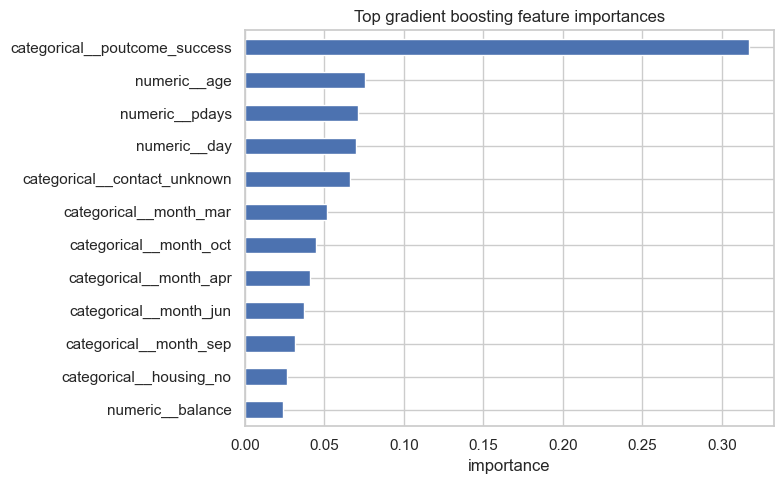

,importance
categorical__poutcome_success,0.316987
numeric__age,0.075630
numeric__pdays,0.071074
numeric__day,0.069779
categorical__contact_unknown,0.065961
categorical__month_mar,0.051308
categorical__month_oct,0.044605
categorical__month_apr,0.041137
categorical__month_jun,0.036889
categorical__month_sep,0.031420


In [10]:
preprocessor = final_boosting.named_steps["preprocess"]
model = final_boosting.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

top_importance = importance.head(12).sort_values()
plt.figure(figsize=(8, 5))
top_importance.plot(kind="barh")
plt.xlabel("importance")
plt.title("Top gradient boosting feature importances")
plt.tight_layout()
plt.show()

display(importance.head(12).to_frame("importance"))


## Practical recommendation

For this dataset, gradient boosting is a reasonable candidate when the goal is better probability ranking and the team can maintain a moderately more complex model. Logistic regression remains a strong baseline because it is fast, stable, and easier to explain.

A practical recommendation should mention:

- **Performance:** compare log loss, balanced accuracy, and F1 rather than accuracy alone.
- **Simplicity:** prefer logistic regression if the gain from boosting is small.
- **Speed:** boosting is slower to train and tune, especially as tree count grows.
- **Maintainability:** pipelines make deployment safer because preprocessing and modeling are packaged together.
- **Deployment risk:** monitor data drift and recalibrate probabilities when campaign behavior changes.

In a production project, we would next tune thresholds based on business costs and evaluate once on the sealed test set.


## Exercises

1. Change the toy learner from `max_depth=1` to `max_depth=2`. How does the fitted shape change?
2. Lower `learning_rate` to `0.02` in the bank model. What happens to the best number of trees?
3. Compare `max_depth=1`, `max_depth=2`, and `max_depth=3` using cross-validation. Which one would you choose and why?
4. Create a threshold table with `threshold_table(y_val, validation_probability)`. Which threshold would you choose if a false negative costs five times a false positive?
5. Remove scaling from the preprocessing pipeline. Which model changes more: logistic regression or gradient boosting?

## Challenge

Write a short model card paragraph for the final gradient boosting model. Include intended use, excluded leakage feature, validation metrics, key limitations, and monitoring needs.

## Summary

Gradient boosting builds an additive model one correction tree at a time. It is powerful for tabular data, but the practical workflow matters as much as the algorithm: start with baselines, keep preprocessing inside pipelines, tune capacity on development data, evaluate validation only once, and explain trade-offs in plain language.

## References

- scikit-learn documentation: `GradientBoostingClassifier`, `Pipeline`, and `ColumnTransformer`.
- Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine.
- UCI Bank Marketing dataset documentation.
